In [5]:
import random
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
sns.set_theme(style="darkgrid", context="talk")

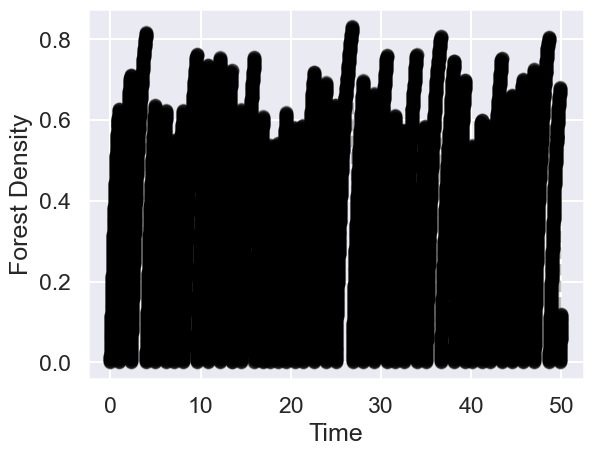

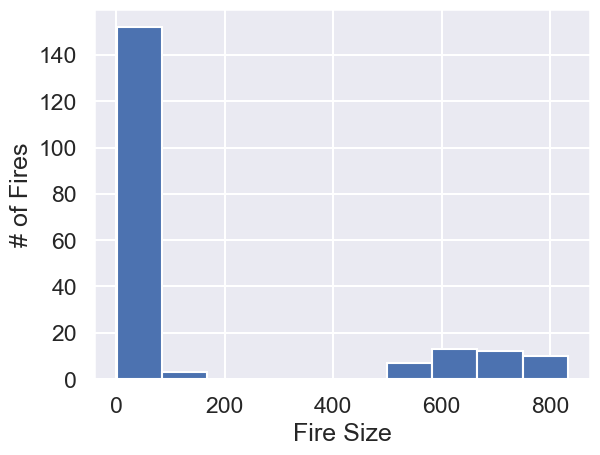

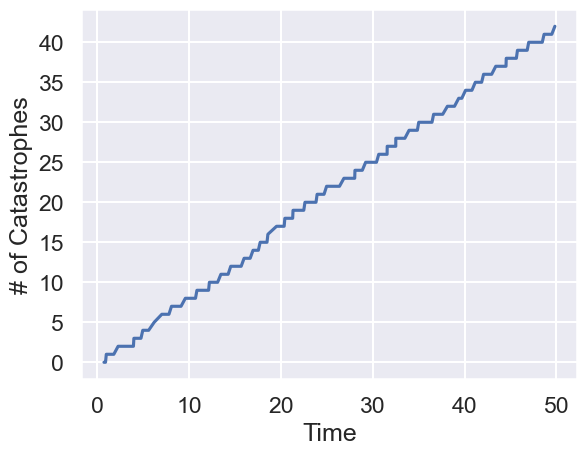

In [49]:
# parameters
L = 1000
growth_rate = 1
lightning_rate = 0.01
T = 50
t = 0
lattice = np.zeros(L, dtype=int)

times = [0]

# track density of forested sites over time
density = [0.0]

# track distribution of fire sizes
fire_sizes = []

# track the frequency of fires that are able to travel across the entire ring (which we call catastrophes)
catastrophes = []
fire_times = []

while t < T:
    smallest_tau = np.inf
    event = None
    event_site = None

    for site in range(L):
        if lattice[site] == 0:  # only empty sites can grow
            tau = np.random.exponential(1 / growth_rate)
            if tau < smallest_tau:
                smallest_tau = tau
                event = 'growth'
                event_site = site

    for site in range(L):
        tau = np.random.exponential(1 / lightning_rate)
        if tau < smallest_tau:
            smallest_tau = tau
            event = 'lightning'
            event_site = site

    if event == 'growth':
        lattice[event_site] = 1

    if event == 'lightning' and lattice[event_site] == 1:
        fire_size = 1
        fire_intensity = 1
        lattice[event_site] = 0
        current_site = event_site
        steps_toward_castastrophe = 0
        # As long as fire intensity is greater to zero
        while fire_intensity > 0:
            current_site = (current_site + 1) % L  # spread to next site
            steps_toward_castastrophe += 1
            if lattice[current_site] == 1:  # forested
                fire_size += 1
                fire_intensity += 1 # gains intensity
                lattice[current_site] = 0  # burns
            else:
                fire_intensity -= 1

        fire_sizes.append(fire_size)
        fire_times.append(t)
        if steps_toward_castastrophe >= L:
            catastrophes.append(1)
        else:
            catastrophes.append(0)

    times.append(t)
        
    density.append(np.mean(lattice))
    t += smallest_tau

plt.plot(times, density, marker="o", ls='--', color='black', alpha=0.25)
plt.ylabel('Forest Density')
plt.xlabel('Time')
plt.show()

plt.hist(fire_sizes)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True)) # fix seaborn float formatting
plt.xlabel('Fire Size')
plt.ylabel('# of Fires')
plt.show()

plt.plot(fire_times, np.cumsum(catastrophes))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True)) # fix seaborn float formatting
plt.xlabel('Time')
plt.ylabel('# of Catastrophes')
plt.show()
